# Detect Heart Disease - Internship

## Dependencies

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Data Initialization

In [2]:
data = pd.read_csv('dataset.csv')

In [3]:
data.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


Shape

In [4]:
data.shape

(1190, 12)

Columns

In [5]:
list(data.columns)

['age',
 'sex',
 'chest pain type',
 'resting bp s',
 'cholesterol',
 'fasting blood sugar',
 'resting ecg',
 'max heart rate',
 'exercise angina',
 'oldpeak',
 'ST slope',
 'target']

Data Info

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB


In [7]:
data.describe()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,53.720168,0.763866,3.232773,132.153782,210.363866,0.213445,0.698319,139.732773,0.387395,0.922773,1.624370,0.528571
std,9.358203,0.424884,0.935480,18.368823,101.420489,0.409912,0.870359,25.517636,0.487360,1.086337,0.610459,0.499393
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,188.000000,0.000000,0.000000,121.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,229.000000,0.000000,0.000000,140.500000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,269.750000,0.000000,2.000000,160.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


**Note:** There is no problem with data hence theres no need of Data cleaning

## Data Cleaning

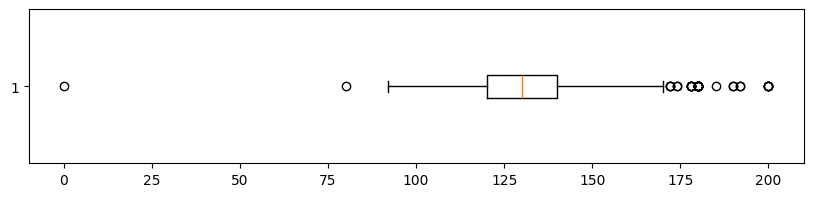

In [8]:
plt.figure(figsize=(10,2))
plt.boxplot(data['resting bp s'],vert=False)
plt.show()

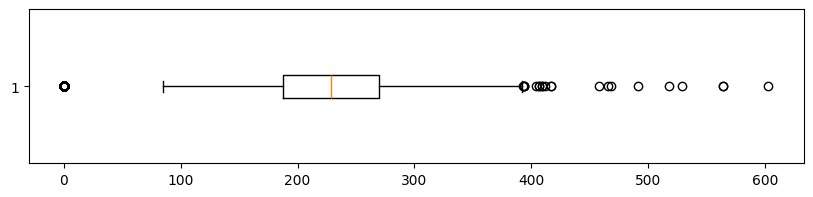

In [9]:
plt.figure(figsize=(10,2))
plt.boxplot(data['cholesterol'],vert=False)
plt.show()

In [10]:
outlier_bloodPressure_index = data[data['resting bp s'] < 75].index

In [11]:
outlier_Cholesterol_index = data[data['cholesterol'] == 0].index

Theres this person having Blood Pressure or Cholesterol be 0 which is impossible for a normal being

In [12]:
cleanedData = data.drop(outlier_bloodPressure_index,axis=0)

In [13]:
cleanedData = data.drop(outlier_Cholesterol_index,axis=0)

## EDA

#### Overall Data

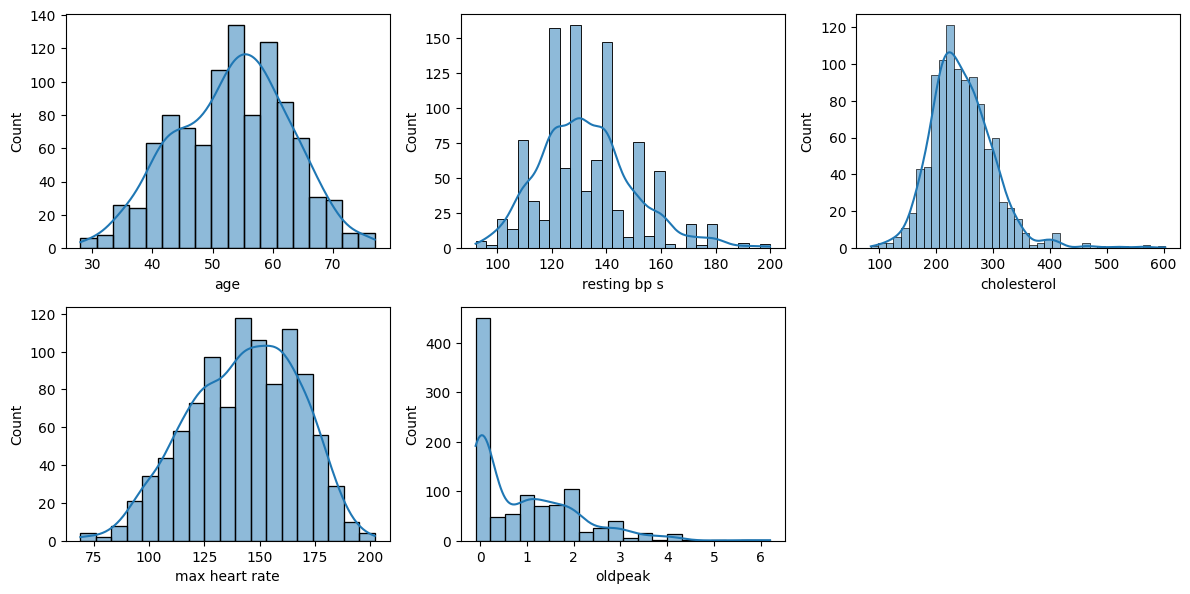

In [15]:
# ...existing code...
fig, axs = plt.subplots(2, 3, figsize=(12, 6))
distributedColumns = ['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak']

for col, ax in zip(distributedColumns, axs.flatten()):
    sns.histplot(cleanedData, x=col, kde=True, ax=ax)
    ax.set_xlabel(col)

# hide the unused subplot (last one)
axs.flatten()[-1].set_visible(False)

plt.tight_layout()
plt.show()
# ...existing code...

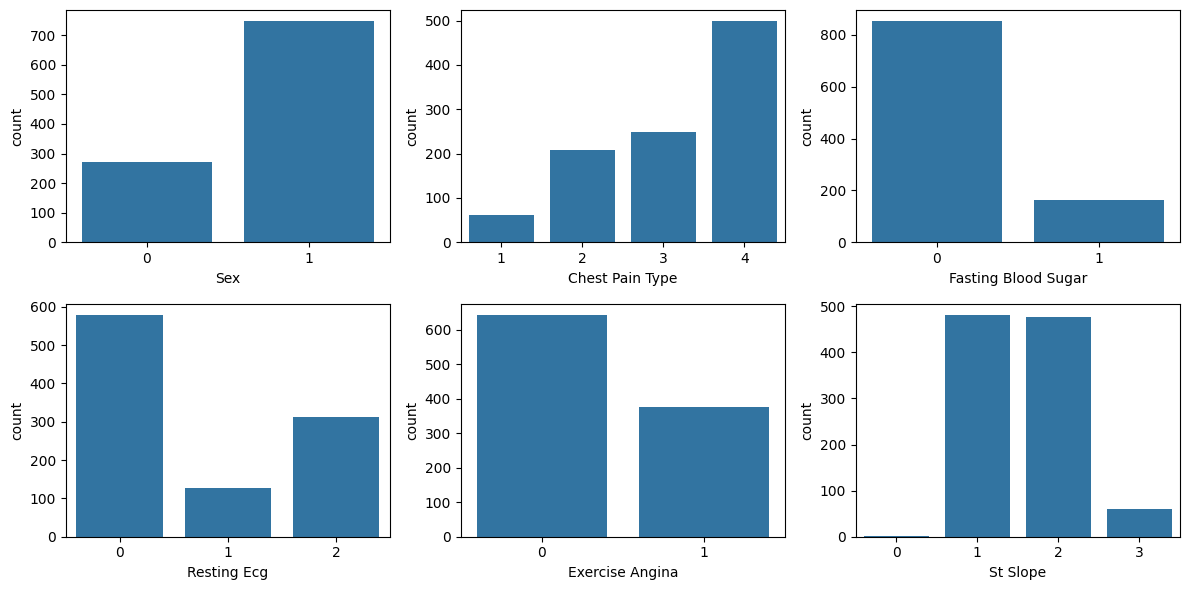

In [17]:
fig, axs = plt.subplots(2, 3, figsize=(12, 6))
categoryColumns = ['sex', 'chest pain type', 'fasting blood sugar', 'resting ecg', 'exercise angina', 'ST slope']

for col, ax in zip(categoryColumns, axs.flatten()):
    ax = sns.countplot(cleanedData, x=col, ax=ax)
    ax.set_xlabel(col.title())

plt.tight_layout()
plt.show()


#### Data of people who have Heart disease

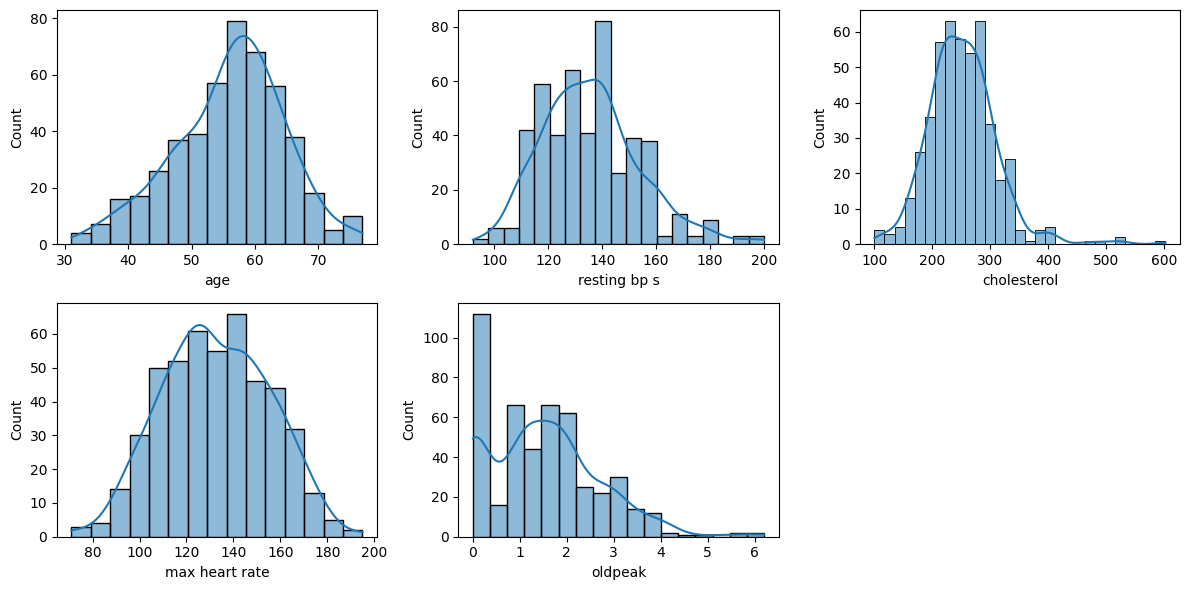

In [24]:
# ...existing code...
fig, axs = plt.subplots(2, 3, figsize=(12, 6))
distributedColumns = ['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak']

for col, ax in zip(distributedColumns, axs.flatten()):
    sns.histplot(cleanedData[cleanedData['target'] == 1], x=col, kde=True, ax=ax)
    ax.set_xlabel(col)

# hide the unused subplot (last one)
axs.flatten()[-1].set_visible(False)

plt.tight_layout()
plt.show()
# ...existing code...

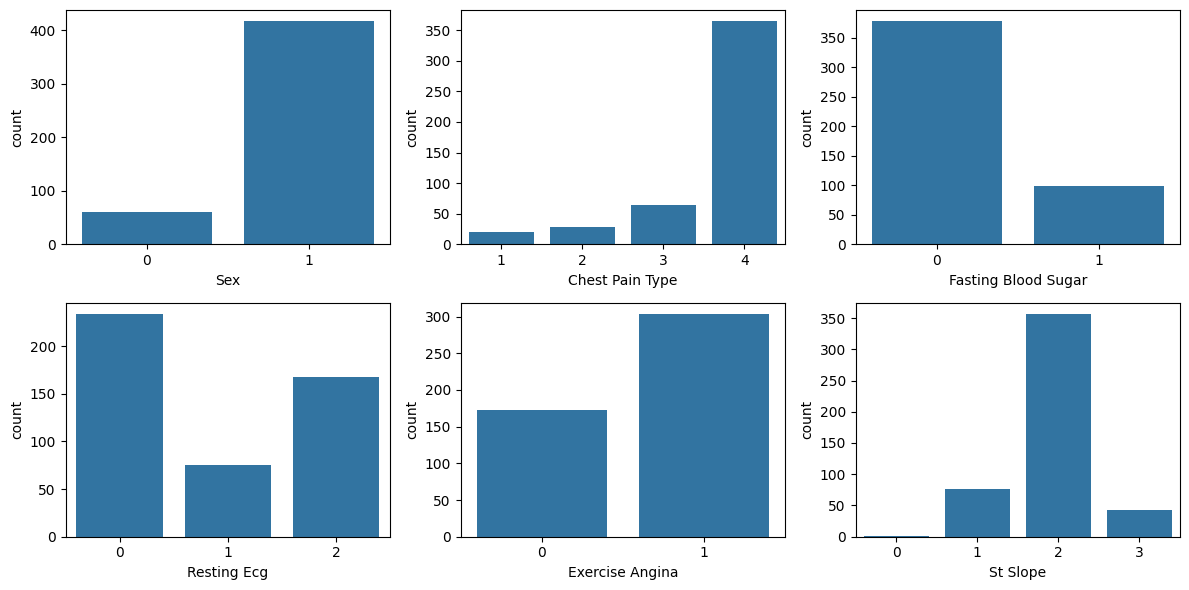

In [25]:
fig, axs = plt.subplots(2, 3, figsize=(12, 6))
categoryColumns = ['sex', 'chest pain type', 'fasting blood sugar', 'resting ecg', 'exercise angina', 'ST slope']

for col, ax in zip(categoryColumns, axs.flatten()):
    ax = sns.countplot(cleanedData[cleanedData['target'] == 1], x=col, ax=ax)
    ax.set_xlabel(col.title())

plt.tight_layout()
plt.show()


## Data Preporcessing

Splitting the Data

In [18]:
X = data.drop(['target'],axis=1)
y = data['target']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

Scaling the Data

In [19]:
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.fit_transform(X_test)

## Model Training and Evaluation

Implementing Random Forest

In [20]:
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(scaled_X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Implementing Logistic Regression

In [21]:
logistics = LogisticRegression(max_iter=10000, random_state=0)
logistics.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


### Evaluation

Random Forest Accuracy

In [22]:
accuracy = accuracy_score(y_test, classifier.predict(scaled_X_test))
print(f'Random Forest model accuracy: {accuracy * 100:.2f}%')

Random Forest model accuracy: 92.02%


Logistic Regression

In [23]:
accuracy = accuracy_score(y_test, logistics.predict(X_test)) 
print(f"Logistic Regression model accuracy: {accuracy * 100:.2f}%")

Logistic Regression model accuracy: 83.61%
